# NICO++ DG_Benchmark Dataset Visualization

This notebook visualizes the distribution of the NICO++ DG_Benchmark dataset across 60 classes and 6 visual contexts.

**Dataset Statistics:**
- Total images: 88,866
- Train: 71,091 (80%)
- Test: 17,775 (20%)
- Classes: 60
- Contexts: 6 (autumn, dim, grass, outdoor, rock, water)

In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load Annotation Data

# Class ID to name mapping
class_names = {
    0: "car", 1: "flower", 2: "chair", 3: "truck", 4: "tiger",
    5: "wheat", 6: "seal", 7: "wolf", 8: "lion", 9: "dolphin",
    10: "lifeboat", 11: "corn", 12: "fishing rod", 13: "owl", 14: "sunflower",
    15: "cow", 16: "bird", 17: "clock", 18: "shrimp", 19: "goose",
    20: "airplane", 21: "rabbit", 22: "hot air balloon", 23: "lizard", 24: "hat",
    25: "spider", 26: "motorcycle", 27: "tortoise", 28: "dog", 29: "crocodile",
    30: "elephant", 31: "gun", 32: "fox", 33: "bus", 34: "cat",
    35: "sailboat", 36: "giraffe", 37: "cactus", 38: "pumpkin", 39: "train",
    40: "ship", 41: "helicopter", 42: "bicycle", 43: "racket", 44: "squirrel",
    45: "bear", 46: "scooter", 47: "mailbox", 48: "horse", 49: "pineapple",
    50: "frog", 51: "football", 52: "ostrich", 53: "tent", 54: "kangaroo",
    55: "monkey", 56: "crab", 57: "sheep", 58: "butterfly", 59: "umbrella"
}

# Contexts and splits
contexts = ['autumn', 'dim', 'grass', 'outdoor', 'rock', 'water']
splits = ['train', 'test']

# Parse annotation files
data_rows = []
annotation_dir = Path('./NICO++/DG_Benchmark/NICO_DG_Benchmark_annotation')

for context in contexts:
    for split in splits:
        annotation_file = annotation_dir / f"{context}_{split}.txt"
        
        with open(annotation_file, 'r') as f:
            for line in f:
                # Use rsplit to handle class names with spaces
                # (e.g., "hot air balloon", "fishing rod")
                parts = line.strip().rsplit(maxsplit=1)
                if len(parts) == 2:
                    image_path = parts[0]
                    class_id = int(parts[1])
                    
                    data_rows.append({
                        'context': context,
                        'split': split,
                        'class_id': class_id,
                        'class_name': class_names[class_id],
                        'image_path': image_path
                    })

# Create DataFrame
df = pd.DataFrame(data_rows)

print(f"Loaded {len(df):,} images")
print(f"Train: {len(df[df['split'] == 'train']):,}")
print(f"Test: {len(df[df['split'] == 'test']):,}")
print(f"\nClasses loaded: {df['class_id'].nunique()}")
print(f"Contexts loaded: {df['context'].nunique()}")
print(f"\nDataFrame preview:")
df.head()

Loaded 88,866 images
Train: 71,091
Test: 17,775

Classes loaded: 60
Contexts loaded: 6

DataFrame preview:


,context,split,class_id,class_name,image_path
0,autumn,train,36,giraffe,NICO_DG/autumn/giraffe/autumn_0000002.jpg
1,autumn,train,26,motorcycle,NICO_DG/autumn/motorcycle/autumn_000130.jpg
2,autumn,train,17,clock,NICO_DG/autumn/clock/autumn_000144.jpg
3,autumn,train,22,hot air balloon,NICO_DG/autumn/hot air balloon/autumn_000063.jpg
4,autumn,train,38,pumpkin,NICO_DG/autumn/pumpkin/autumn_000171.jpg


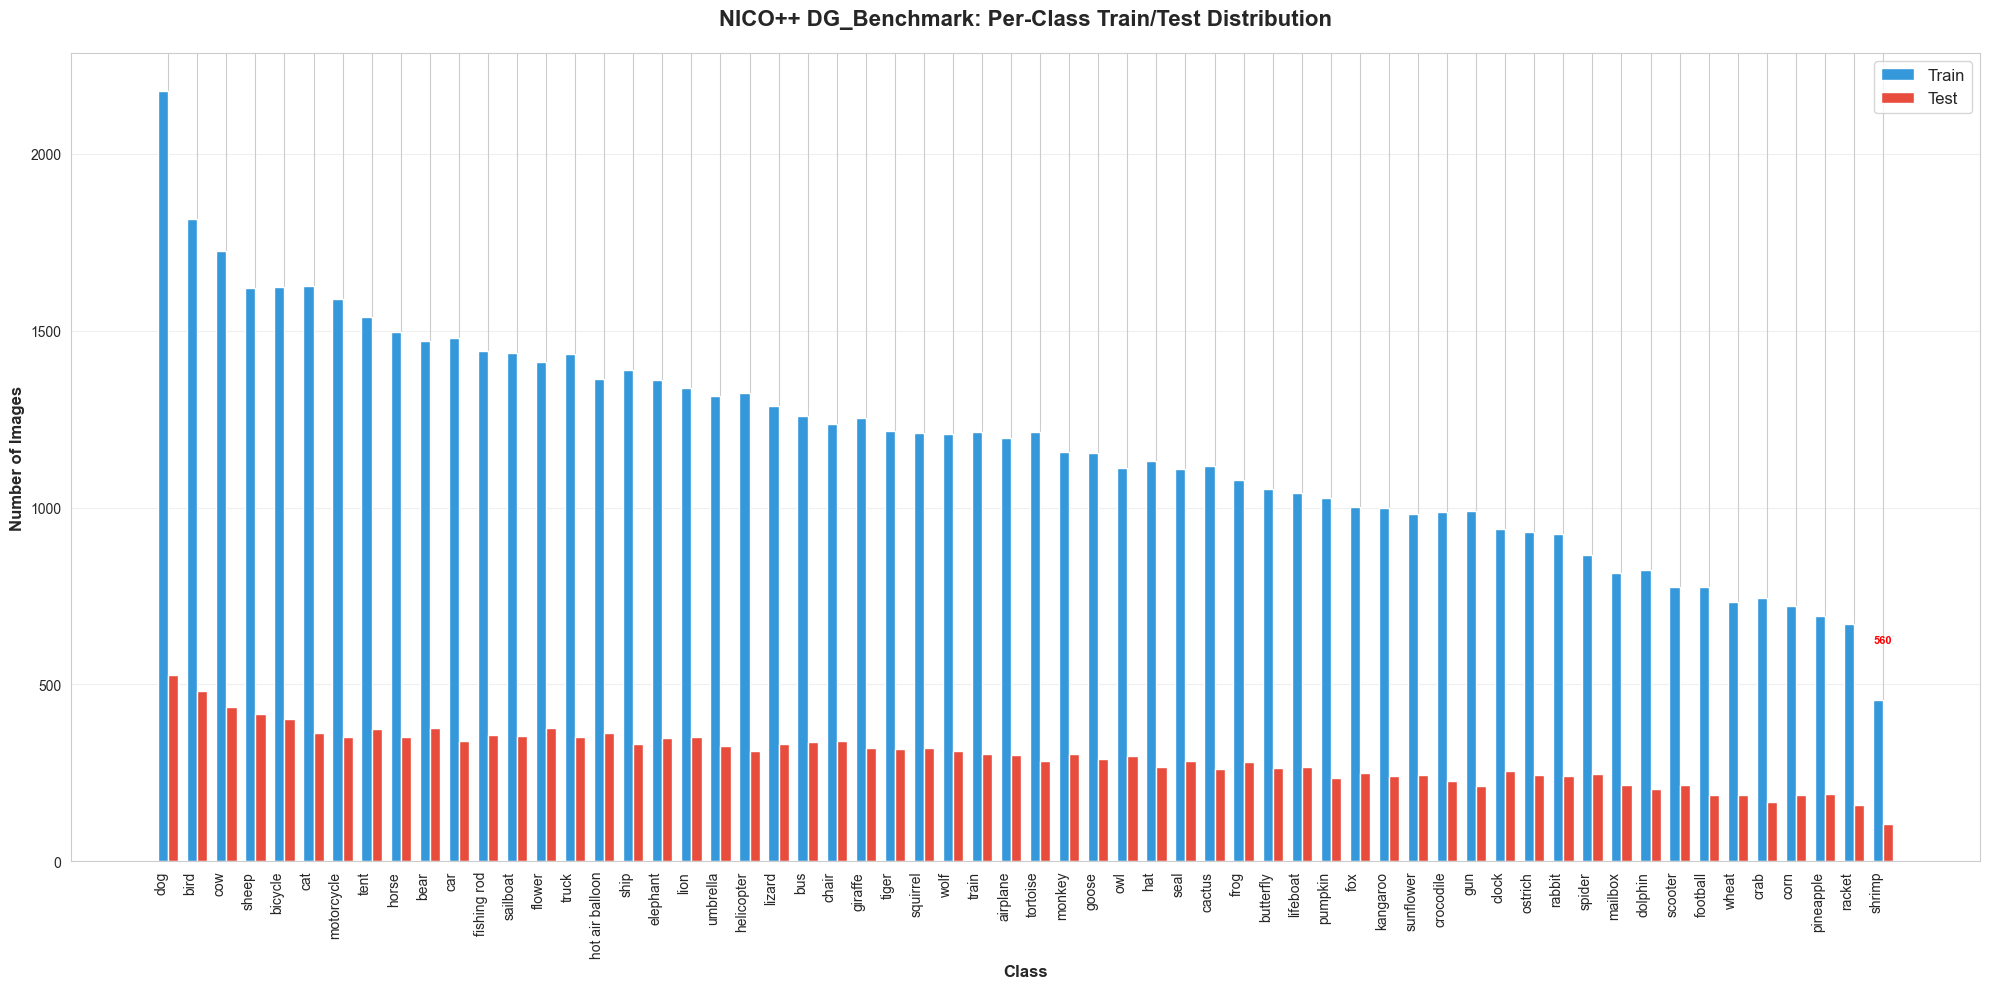


Top 5 largest classes:
split       test  train  total
class_name                    
dog          526   2177   2703
bird         482   1817   2299
cow          437   1725   2162
sheep        416   1620   2036
bicycle      401   1623   2024

Top 5 smallest classes:
split       test  train  total
class_name                    
crab         167    743    910
corn         187    721    908
pineapple    191    694    885
racket       159    671    830
shrimp       105    455    560


In [3]:
# Cell 3: Visualization 1 - Per-Class Distribution

# Aggregate per-class counts
class_stats = df.groupby(['class_name', 'split']).size().unstack(fill_value=0)
class_stats['total'] = class_stats['train'] + class_stats['test']
class_stats = class_stats.sort_values('total', ascending=False)

# Create bar chart
fig, ax = plt.subplots(figsize=(20, 10))

x = np.arange(len(class_stats))
width = 0.35

bars1 = ax.bar(x - width/2, class_stats['train'], width, label='Train', color='#3498db')
bars2 = ax.bar(x + width/2, class_stats['test'], width, label='Test', color='#e74c3c')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('NICO++ DG_Benchmark: Per-Class Train/Test Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(class_stats.index, rotation=90, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Highlight smallest classes (< 600 total)
for i, (idx, row) in enumerate(class_stats.iterrows()):
    if row['total'] < 600:
        ax.text(i, row['total'] + 50, f"{int(row['total'])}", 
                ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 5 largest classes:")
print(class_stats.head())
print("\nTop 5 smallest classes:")
print(class_stats.tail())

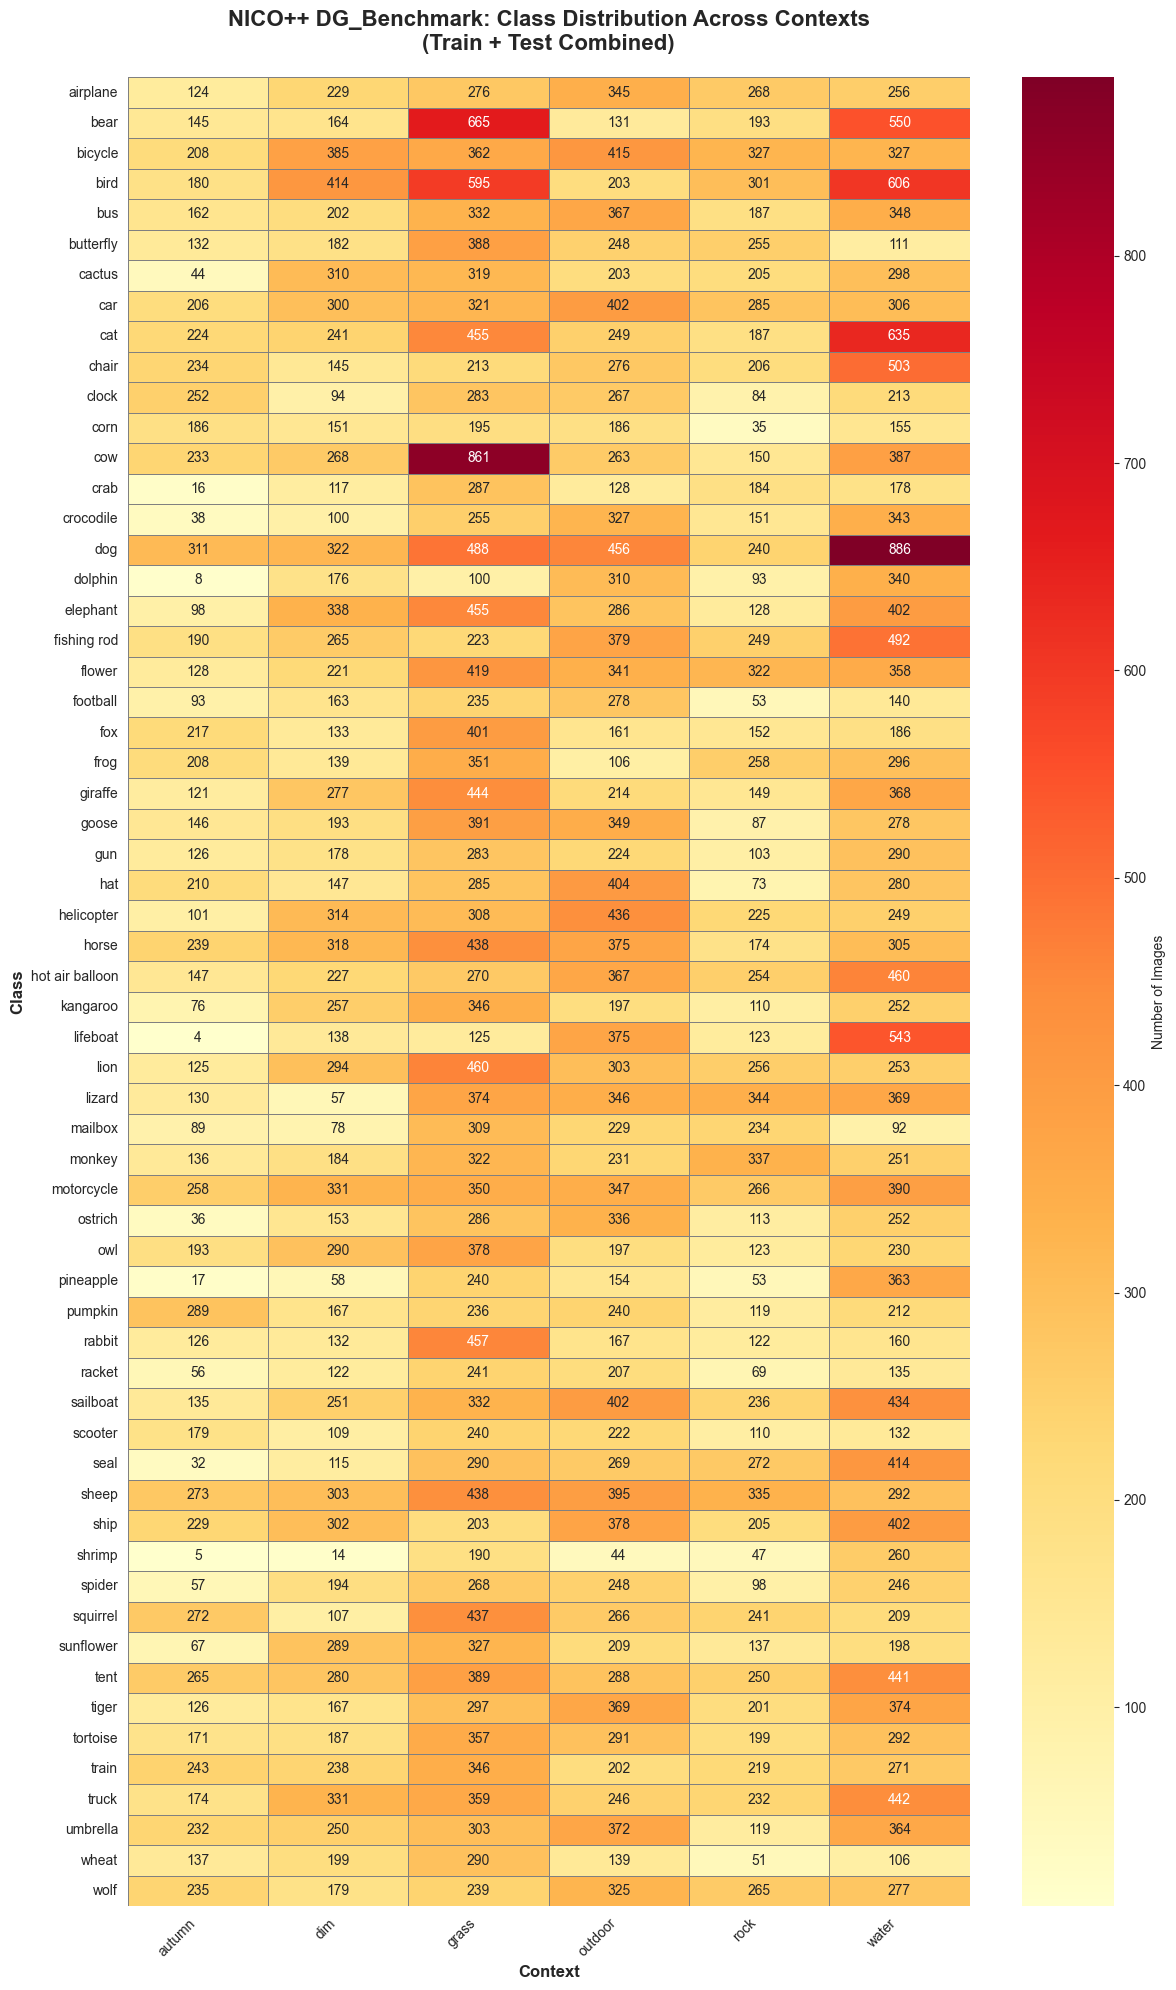


Class-Context combinations with < 20 images:
       Class Context  Count
2   lifeboat  autumn      4
4     shrimp  autumn      5
1    dolphin  autumn      8
5     shrimp     dim     14
0       crab  autumn     16
3  pineapple  autumn     17


In [4]:
# Cell 4: Visualization 2 - Per-Class Per-Context Heatmap

# Create pivot table: classes × contexts
heatmap_data = df.groupby(['class_name', 'context']).size().unstack(fill_value=0)

# Sort classes alphabetically for readability
heatmap_data = heatmap_data.sort_index()

# Reorder contexts
context_order = ['autumn', 'dim', 'grass', 'outdoor', 'rock', 'water']
heatmap_data = heatmap_data[context_order]

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 20))

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Images'},
            linewidths=0.5,
            linecolor='gray',
            ax=ax)

ax.set_title('NICO++ DG_Benchmark: Class Distribution Across Contexts\n(Train + Test Combined)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Context', fontsize=12, fontweight='bold')
ax.set_ylabel('Class', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Identify sparse class-context combinations
print("\nClass-Context combinations with < 20 images:")
sparse = []
for idx in heatmap_data.index:
    for col in heatmap_data.columns:
        if heatmap_data.loc[idx, col] < 20 and heatmap_data.loc[idx, col] > 0:
            sparse.append((idx, col, heatmap_data.loc[idx, col]))

sparse_df = pd.DataFrame(sparse, columns=['Class', 'Context', 'Count']).sort_values('Count')
print(sparse_df.head(10))

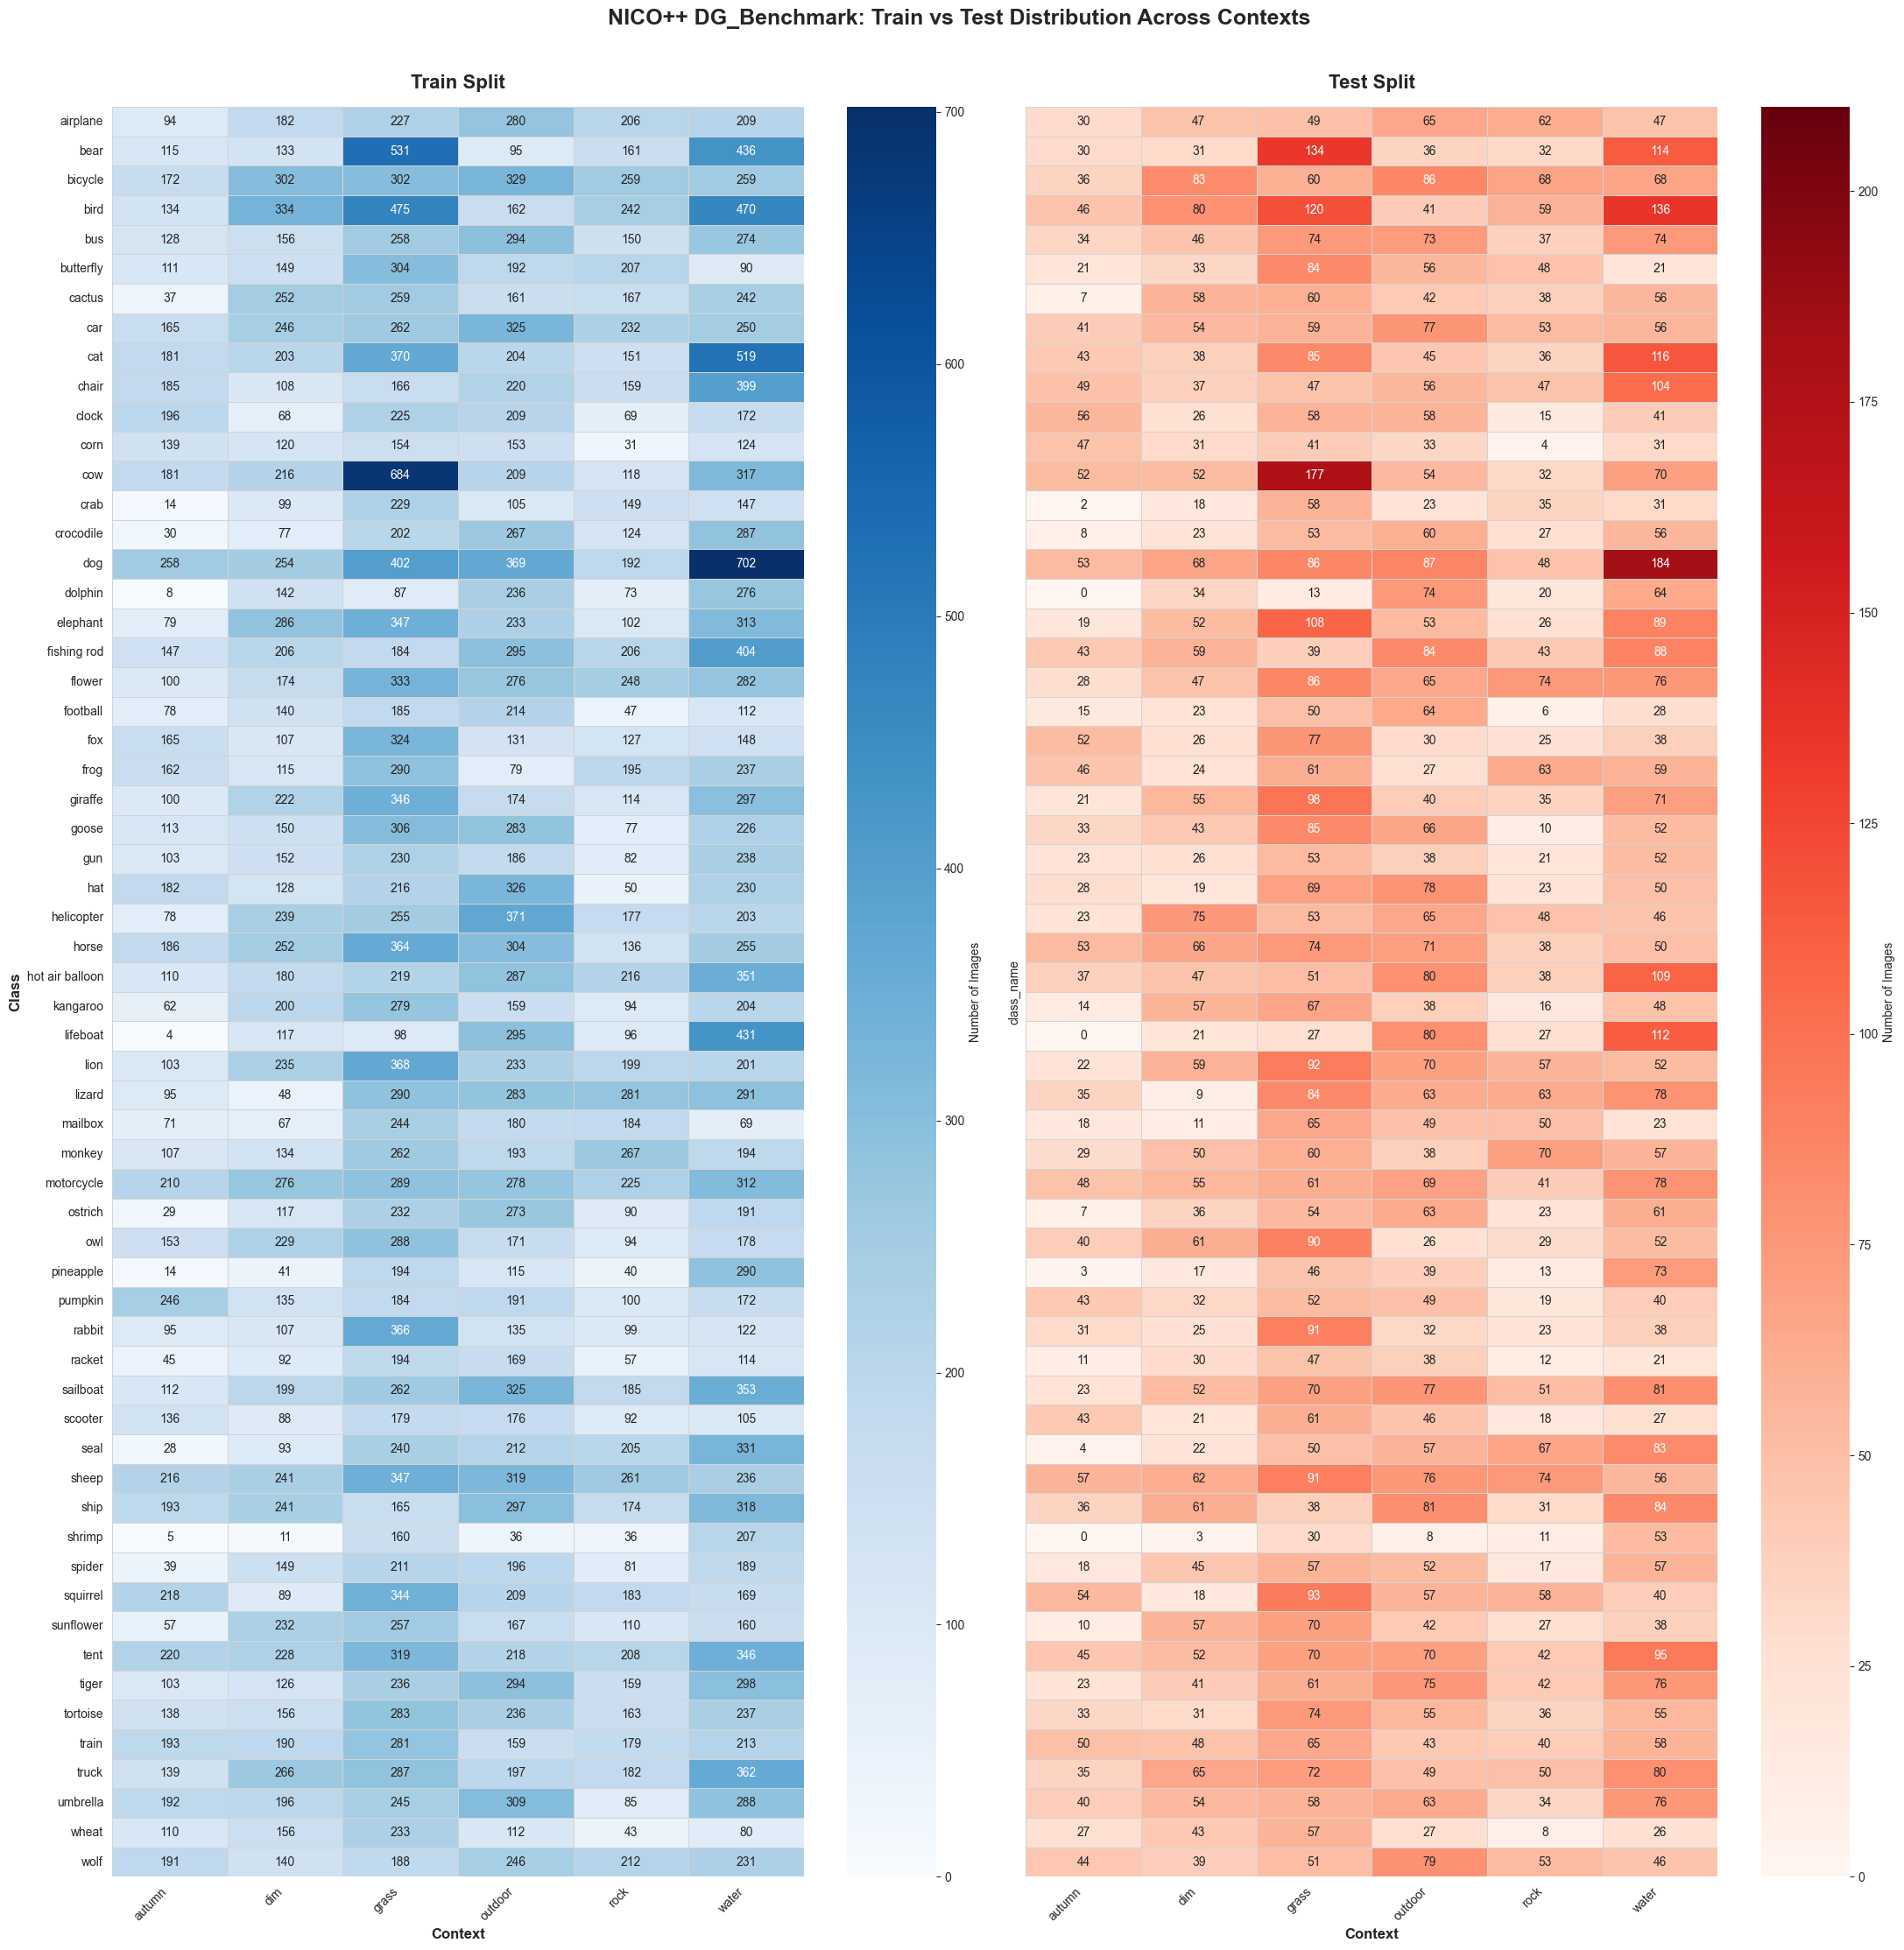


Classes with most skewed train/test ratio per context (top 5):

  autumn:
    crab: 7.0:1 (train=14, test=2)
    seal: 7.0:1 (train=28, test=4)
    hat: 6.5:1 (train=182, test=28)

  dim:
    hat: 6.7:1 (train=128, test=19)
    mailbox: 6.1:1 (train=67, test=11)
    football: 6.1:1 (train=140, test=23)

  grass:
    dolphin: 6.7:1 (train=87, test=13)
    shrimp: 5.3:1 (train=160, test=30)
    bicycle: 5.0:1 (train=302, test=60)

  outdoor:
    owl: 6.6:1 (train=171, test=26)
    helicopter: 5.7:1 (train=371, test=65)
    monkey: 5.1:1 (train=193, test=38)

  rock:
    football: 7.8:1 (train=47, test=6)
    corn: 7.8:1 (train=31, test=4)
    goose: 7.7:1 (train=77, test=10)

  water:
    racket: 5.4:1 (train=114, test=21)
    crocodile: 5.1:1 (train=287, test=56)
    horse: 5.1:1 (train=255, test=50)


In [5]:
# Cell 5: Visualization 3 - Train vs Test Heatmaps (Side-by-Side)

# Build separate pivot tables for train and test
train_data = df[df['split'] == 'train'].groupby(['class_name', 'context']).size().unstack(fill_value=0)
test_data = df[df['split'] == 'test'].groupby(['class_name', 'context']).size().unstack(fill_value=0)

# Ensure both have same index/columns (fill missing with 0)
all_classes = sorted(df['class_name'].unique())
context_order = ['autumn', 'dim', 'grass', 'outdoor', 'rock', 'water']

train_data = train_data.reindex(index=all_classes, columns=context_order, fill_value=0)
test_data = test_data.reindex(index=all_classes, columns=context_order, fill_value=0)

# Use a shared color scale so train and test are directly comparable
vmin = 0
vmax = max(train_data.values.max(), test_data.values.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 22), sharey=True)

# Train heatmap
sns.heatmap(train_data,
            annot=True,
            fmt='d',
            cmap='Blues',
            vmin=vmin,
            vmax=vmax,
            cbar_kws={'label': 'Number of Images'},
            linewidths=0.5,
            linecolor='lightgray',
            ax=ax1)
ax1.set_title('Train Split', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Context', fontsize=12, fontweight='bold')
ax1.set_ylabel('Class', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Test heatmap
sns.heatmap(test_data,
            annot=True,
            fmt='d',
            cmap='Reds',
            vmin=vmin,
            vmax=int(vmax * 0.3),  # Scale test colorbar to its own range for visibility
            cbar_kws={'label': 'Number of Images'},
            linewidths=0.5,
            linecolor='lightgray',
            ax=ax2)
ax2.set_title('Test Split', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Context', fontsize=12, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('NICO++ DG_Benchmark: Train vs Test Distribution Across Contexts',
             fontsize=18, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

# Print classes with the largest train/test ratio imbalance per context
print("\nClasses with most skewed train/test ratio per context (top 5):")
ratio_data = train_data / test_data.replace(0, np.nan)
for ctx in context_order:
    top = ratio_data[ctx].dropna().sort_values(ascending=False).head(3)
    bottom = ratio_data[ctx].dropna().sort_values(ascending=True).head(2)
    print(f"\n  {ctx}:")
    for cls, r in top.items():
        print(f"    {cls}: {r:.1f}:1 (train={train_data.loc[cls, ctx]}, test={test_data.loc[cls, ctx]})")

In [6]:
# Cell 5: Summary Statistics

print("=" * 80)
print("NICO++ DG_Benchmark Dataset Summary")
print("=" * 80)

# Overall split
total_train = len(df[df['split'] == 'train'])
total_test = len(df[df['split'] == 'test'])
total = len(df)

print(f"\n📊 Overall Statistics:")
print(f"  Total images: {total:,}")
print(f"  Train: {total_train:,} ({100*total_train/total:.1f}%)")
print(f"  Test: {total_test:,} ({100*total_test/total:.1f}%)")

# Context distribution
context_stats = df.groupby(['context', 'split']).size().unstack(fill_value=0)
context_stats['total'] = context_stats['train'] + context_stats['test']
context_stats['percentage'] = 100 * context_stats['total'] / total

print(f"\n🌍 Context Distribution:")
print(context_stats.to_string())

# Class distribution
class_totals = df.groupby('class_name').size().sort_values(ascending=False)

print(f"\n🔝 Top 5 Largest Classes:")
for i, (cls, count) in enumerate(class_totals.head().items(), 1):
    print(f"  {i}. {cls}: {count:,} images")

print(f"\n🔻 Top 5 Smallest Classes:")
for i, (cls, count) in enumerate(class_totals.tail().items(), 1):
    print(f"  {i}. {cls}: {count:,} images")

# Classes with 0 test images in any context
print(f"\n⚠️  Classes with 0 Test Images in Some Contexts:")
for context in contexts:
    context_test = df[(df['context'] == context) & (df['split'] == 'test')]
    missing_classes = set(range(60)) - set(context_test['class_id'].unique())
    if missing_classes:
        missing_names = [class_names[cid] for cid in sorted(missing_classes)]
        print(f"  {context}: {', '.join(missing_names)}")

# Imbalance metrics
max_context = context_stats['total'].idxmax()
min_context = context_stats['total'].idxmin()
ratio = context_stats.loc[max_context, 'total'] / context_stats.loc[min_context, 'total']

print(f"\n⚖️  Context Imbalance:")
print(f"  Largest context: {max_context} ({context_stats.loc[max_context, 'total']:,} images)")
print(f"  Smallest context: {min_context} ({context_stats.loc[min_context, 'total']:,} images)")
print(f"  Ratio: {ratio:.2f}× difference")

print("\n" + "=" * 80)

NICO++ DG_Benchmark Dataset Summary

📊 Overall Statistics:
  Total images: 88,866
  Train: 71,091 (80.0%)
  Test: 17,775 (20.0%)

🌍 Context Distribution:
split    test  train  total  percentage
context                                
autumn   1819   7275   9094   10.233385
dim      2498   9991  12489   14.053744
grass    4066  16261  20327   22.873765
outdoor  3338  13352  16690   18.781086
rock     2213   8851  11064   12.450206
water    3841  15361  19202   21.607814

🔝 Top 5 Largest Classes:
  1. dog: 2,703 images
  2. bird: 2,299 images
  3. cow: 2,162 images
  4. sheep: 2,036 images
  5. bicycle: 2,024 images

🔻 Top 5 Smallest Classes:
  1. crab: 910 images
  2. corn: 908 images
  3. pineapple: 885 images
  4. racket: 830 images
  5. shrimp: 560 images

⚠️  Classes with 0 Test Images in Some Contexts:
  autumn: dolphin, lifeboat, shrimp

⚖️  Context Imbalance:
  Largest context: grass (20,327 images)
  Smallest context: autumn (9,094 images)
  Ratio: 2.24× difference

